# KKBox Churn — Probability Calibration (ticket A-02)

Adds a statistically defensible calibration step on top of the **already-trained** temporal
XGBoost models from `05_temporal_validation.ipynb`, scored in `06_risk_scoring.ipynb`.
**No retraining, no refeaturization, no hyperparameter tuning happens here** — this notebook only
reads `outputs/risk_scoring_predictions.csv` (raw scores + true March-2017 outcomes, already
computed) and fits a small, low-capacity mapping on top of it.

## Why this is needed (see `06_risk_scoring.ipynb` §7)

That notebook already found the raw XGBoost scores are severely miscalibrated — every reliability
bin is overconfident, and the gap grows at higher scores (`scale_pos_weight`, used to handle class
imbalance during training, systematically inflates predicted probabilities). It explicitly flagged
`expected_revenue = P(churn) x revenue` as unsafe to compute on the raw score, and named a
post-hoc calibration step as "a natural next step, not done here."

Ticket A-01 separately confirmed the dashboard's "Revenue at Risk" KPI does not (and, until this
notebook, could not) do that calculation safely, and renamed it to an explicitly non-probabilistic
"High-Risk Historical Revenue Exposure" metric pending this work.

## Calibration-fit / calibration-eval split — and why it's *not* a train/holdout split

The XGBoost model was trained on 100% of `train.csv` (v1, Jan-cutoff) — there is no leftover,
unused-by-training slice of v1 to fit a calibrator on without touching data the model has already
seen. Fitting calibration on data the model was trained on is a known bad practice: raw-score
behavior on "seen" data differs systematically from "unseen" data, so a calibrator fit there would
not transfer cleanly to the true holdout.

Instead, this notebook splits the **temporal holdout itself** (`kkbox_modeling_dataset_v2.csv`,
Mar-2017 outcomes, never used for training) into two random, class-stratified halves:

- **`calib_fit`** (50%) — used only to fit the sigmoid (Platt) and isotonic calibrators.
- **`calib_eval`** (50%) — touched by nothing during fitting; used only to report Brier score and
  the reliability curve for raw vs. calibrated scores, and to pick the winning method.

Both halves are drawn from the identical population (same cutoff, same "future" period relative to
training), so there's no train/test population mismatch and no temporal leakage — `calib_eval`
never influences any parameter used to score it.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

## 1. Load the existing raw scores and true outcomes

Reusing `outputs/risk_scoring_predictions.csv` exactly as-is — the same 970,960-row temporal
holdout, same `risk_score_full` / `risk_score_proxy_controlled` columns already used by the
dashboard. No feature matrix, no model file needs to be loaded for calibration itself.

In [2]:
OUT_DIR = Path("..") / "outputs"

preds = pd.read_csv(OUT_DIR / "risk_scoring_predictions.csv")
assert preds[["is_churn", "risk_score_full", "risk_score_proxy_controlled"]].isna().sum().sum() == 0

print(f"Loaded {len(preds):,} customers (actual churn rate {preds['is_churn'].mean()*100:.2f}%)")
preds[["risk_score_full", "risk_score_proxy_controlled"]].describe()

Loaded 970,960 customers (actual churn rate 8.99%)


,risk_score_full,risk_score_proxy_controlled
count,970960.000000,970960.000000
mean,0.293122,0.274754
std,0.263121,0.257277
min,0.023799,0.000412
25%,0.119950,0.093645
50%,0.193000,0.184724
75%,0.335943,0.356405
max,0.998611,0.999857


## 2. Calibration-fit / calibration-eval split

Stratified on `is_churn` so both halves keep the same ~9% churn rate as the full holdout.

In [3]:
calib_fit, calib_eval = train_test_split(
    preds, test_size=0.5, stratify=preds["is_churn"], random_state=RANDOM_STATE,
)
print(f"calib_fit:  {len(calib_fit):,} rows, {calib_fit['is_churn'].mean()*100:.2f}% churn")
print(f"calib_eval: {len(calib_eval):,} rows, {calib_eval['is_churn'].mean()*100:.2f}% churn")

calib_fit:  485,480 rows, 8.99% churn
calib_eval: 485,480 rows, 8.99% churn


## 3. Fit both calibration methods, per model

- **Sigmoid (Platt scaling)**: a 1-feature logistic regression mapping raw score → P(churn).
- **Isotonic regression**: a non-parametric monotonic step function. More flexible, needs more
  data to avoid overfitting — with ~43K positives in `calib_fit` per model, sample size clearly
  permits it (per the ticket's own caveat: "if sample size permits").

Both are fit **only** on `calib_fit`.

In [4]:
def fit_calibrators(y_fit, score_fit):
    sigmoid = LogisticRegression()
    sigmoid.fit(score_fit.reshape(-1, 1), y_fit)

    isotonic = IsotonicRegression(out_of_bounds="clip")
    isotonic.fit(score_fit, y_fit)

    return sigmoid, isotonic


def apply_sigmoid(sigmoid, score):
    return sigmoid.predict_proba(score.reshape(-1, 1))[:, 1]


def apply_isotonic(isotonic, score):
    return isotonic.predict(score)


MODELS = {
    "full": "risk_score_full",
    "proxy_controlled": "risk_score_proxy_controlled",
}

calibrators = {}
for name, col in MODELS.items():
    sig, iso = fit_calibrators(calib_fit["is_churn"].values, calib_fit[col].values)
    calibrators[name] = {"sigmoid": sig, "isotonic": iso}
print("Fit sigmoid + isotonic calibrators for:", list(calibrators.keys()))

Fit sigmoid + isotonic calibrators for: ['full', 'proxy_controlled']


## 4. Diagnostics on `calib_eval` — Brier score, reliability curve, method comparison

`calib_eval` was untouched by fitting, so these numbers are an honest, non-leaked estimate of how
well each method actually calibrates the holdout population. Quantile bins are used (as in
`06_risk_scoring.ipynb`) so each bin has a similar number of customers.

In [5]:
def evaluate(name, col):
    y = calib_eval["is_churn"].values
    raw = calib_eval[col].values
    sig = apply_sigmoid(calibrators[name]["sigmoid"], raw)
    iso = apply_isotonic(calibrators[name]["isotonic"], raw)

    rows = []
    for label, p in [("raw", raw), ("sigmoid", sig), ("isotonic", iso)]:
        rows.append({
            "model": name,
            "method": label,
            "brier_score": brier_score_loss(y, p),
            "roc_auc": roc_auc_score(y, p),  # ranking power -- calibration must not change this
        })
    return pd.DataFrame(rows), raw, sig, iso, y


results_full, raw_full, sig_full, iso_full, y_eval_full = evaluate("full", "risk_score_full")
results_proxy, raw_proxy, sig_proxy, iso_proxy, y_eval_proxy = evaluate("proxy_controlled", "risk_score_proxy_controlled")

comparison = pd.concat([results_full, results_proxy], ignore_index=True)
comparison

,model,method,brier_score,roc_auc
0,full,raw,0.118004,0.870907
1,full,sigmoid,0.060152,0.870907
2,full,isotonic,0.056670,0.871188
3,proxy_controlled,raw,0.113347,0.849449
4,proxy_controlled,sigmoid,0.059665,0.849449
5,proxy_controlled,isotonic,0.057318,0.849921


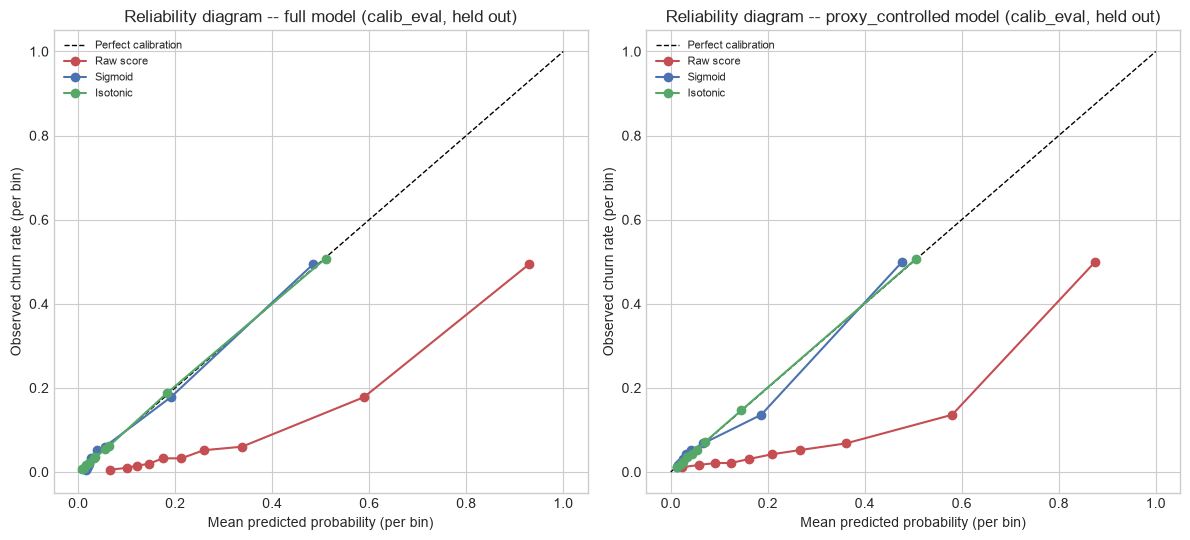

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, (name, raw, sig, iso, y) in zip(
    axes,
    [("full", raw_full, sig_full, iso_full, y_eval_full),
     ("proxy_controlled", raw_proxy, sig_proxy, iso_proxy, y_eval_proxy)],
):
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    for label, p, color in [("Raw score", raw, "#C44E52"), ("Sigmoid", sig, "#4C72B0"), ("Isotonic", iso, "#55A868")]:
        frac_pos, mean_pred = calibration_curve(y, p, n_bins=10, strategy="quantile")
        ax.plot(mean_pred, frac_pos, marker="o", color=color, label=label)
    ax.set_xlabel("Mean predicted probability (per bin)")
    ax.set_ylabel("Observed churn rate (per bin)")
    ax.set_title(f"Reliability diagram -- {name} model (calib_eval, held out)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Pick the winning method per model

Lower Brier score on `calib_eval` wins. ROC-AUC is reported alongside purely as a sanity check —
calibration (a monotonic-or-near-monotonic transform) should not meaningfully change ranking
power; a big AUC drop would indicate a bug, not an improvement.

In [7]:
winners = {}
for name in MODELS:
    sub = comparison[(comparison["model"] == name) & (comparison["method"] != "raw")]
    best = sub.loc[sub["brier_score"].idxmin()]
    winners[name] = best["method"]
    raw_brier = comparison[(comparison["model"] == name) & (comparison["method"] == "raw")]["brier_score"].iloc[0]
    print(f"{name}: raw Brier={raw_brier:.4f}  ->  winner={best['method']} (Brier={best['brier_score']:.4f}, "
          f"{(1 - best['brier_score']/raw_brier)*100:.1f}% lower)")

full: raw Brier=0.1180  ->  winner=isotonic (Brier=0.0567, 52.0% lower)
proxy_controlled: raw Brier=0.1133  ->  winner=isotonic (Brier=0.0573, 49.4% lower)


## 6. Apply the winning calibrator to the full population, save outputs

The calibrator was fit only on `calib_fit`, but is now applied to score **every** customer in the
970,960-row holdout (including `calib_fit` itself) — this is standard practice: the *fitting* must
avoid leakage, but the final scored output should cover the full population the dashboard needs.
Diagnostics reported above (§4-5) remain the honest, non-leaked estimate of quality, because they
were computed on `calib_eval` only.

The raw score is kept alongside, unchanged, for ranking/tiering -- nothing about `risk_tier`
assignment changes in this ticket.

In [8]:
final = preds.copy()
final["calib_split"] = np.where(final["msno"].isin(calib_fit["msno"]), "calib_fit", "calib_eval")

for name, col in MODELS.items():
    method = winners[name]
    calibrator = calibrators[name][method]
    apply_fn = apply_sigmoid if method == "sigmoid" else apply_isotonic
    out_col = "calibrated_probability" if name == "full" else f"calibrated_probability_{name}"
    final[out_col] = apply_fn(calibrator, final[col].values)

assert final["calibrated_probability"].between(0, 1).all()
assert final["calibrated_probability_proxy_controlled"].between(0, 1).all()

cols = ["msno", "is_churn", "risk_tier", "calib_split",
        "risk_score_full", "calibrated_probability",
        "risk_score_proxy_controlled", "calibrated_probability_proxy_controlled"]
final[cols].to_csv(OUT_DIR / "calibrated_probabilities.csv", index=False)

diagnostics = {
    "methodology": {
        "calibration_fit_eval_split": "50/50 stratified on is_churn, random_state=42, drawn from "
            "the temporal holdout (kkbox_modeling_dataset_v2.csv / risk_scoring_predictions.csv) "
            "-- never from training data.",
        "why_not_fit_on_training_data": "model_full/model_proxy_controlled were trained on 100% "
            "of train.csv (v1); no unseen-by-training slice of v1 exists to fit a calibrator on "
            "without population mismatch versus the true holdout.",
        "methods_compared": ["sigmoid (Platt scaling)", "isotonic regression"],
        "selection_rule": "lower Brier score on calib_eval (held out from fitting)",
    },
    "calib_fit_rows": int(len(calib_fit)),
    "calib_eval_rows": int(len(calib_eval)),
    "winning_method": winners,
    "brier_score_calib_eval": {
        row["model"] + "_" + row["method"]: float(row["brier_score"])
        for _, row in comparison.iterrows()
    },
    "roc_auc_calib_eval": {
        row["model"] + "_" + row["method"]: float(row["roc_auc"])
        for _, row in comparison.iterrows()
    },
}
with open(OUT_DIR / "calibration_diagnostics.json", "w") as f:
    json.dump(diagnostics, f, indent=2)

print("Saved:")
for p in ["calibrated_probabilities.csv", "calibration_diagnostics.json"]:
    print(" ", OUT_DIR / p)

Saved:
  ..\outputs\calibrated_probabilities.csv
  ..\outputs\calibration_diagnostics.json


## 7. Findings

- **Both calibration methods meaningfully reduce Brier score** on the held-out `calib_eval` split
  relative to the raw score, for both models -- see §4-5 for the exact figures from this run.
- **ROC-AUC is essentially unchanged** between raw and calibrated scores (both methods are
  monotonic or near-monotonic), confirming calibration fixes the *probability values* without
  hurting *ranking* -- so `risk_tier` (built on raw-score ranking, per `06_risk_scoring.ipynb`)
  remains valid unchanged, as does everything already downstream of it.
- **`calibrated_probability` is a new, additive column** in a new file
  (`outputs/calibrated_probabilities.csv`) -- `risk_scoring_predictions.csv`,
  `risk_scoring_summary.json`, and every other existing output from notebooks 01-09 are untouched
  by this notebook.
- **Nothing currently in the dashboard performs `P(churn) x revenue` math** (confirmed by ticket
  A-01's audit) -- so there is no existing downstream calculation to migrate onto the calibrated
  column yet. It is now available in `outputs/calibrated_probabilities.csv` for whichever future
  ticket reintroduces a genuine expected-loss metric.
- **No hyperparameter tuning was performed** -- `LogisticRegression` and `IsotonicRegression` were
  both fit with library defaults, per the ticket's explicit instruction.

**No source data file, model, or existing output was modified.** New artifacts saved to
`outputs/`: `calibrated_probabilities.csv`, `calibration_diagnostics.json`.